<a href="https://colab.research.google.com/github/srushtisonawale8/Data-Analytics-Microproject/blob/main/Data_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
import warnings

In this step, we import all the necessary libraries required for data analysis, visualization, and machine learning.  
-NumPy and Pandas are used for data manipulation and handling datasets.  
-Matplotlib and Seaborn help in visualizing the data through graphs and charts.  
-Scikit-learn provides tools for preprocessing, splitting the dataset, and building machine learning models.  
-The warnings library is used to ignore unnecessary warnings for cleaner output.

In [15]:
# Loading the dataset from the uploaded CSV file
df = pd.read_csv('cardekho.csv')

# Displaying first 5 rows to understand the data structure
print("First 5 Rows of the cardekho dataset:")
display(df.head())

# Displaying shape of dataset (Rows, Columns)
print("\nDataset Shape:")
print(df.shape)

# Displaying data types of each column
print("\nColumn Data Types:")
print(df.dtypes)

First 5 Rows of the cardekho dataset:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0



Dataset Shape:
(8128, 12)

Column Data Types:
name                   object
year                    int64
selling_price           int64
km_driven               int64
fuel                   object
seller_type            object
transmission           object
owner                  object
mileage(km/ltr/kg)    float64
engine                float64
max_power              object
seats                 float64
dtype: object


In [4]:
# Checking the missing values in the dataset
missing_data = df.isnull().sum()

# Fill numerical columns with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Fill categorical columns with mode
df.fillna(df.mode().iloc[0], inplace=True)

# Check again
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage(km/ltr/kg),0
engine,0


In [5]:
# Checkiing the number of duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Verify again
print("After removing duplicates:", df.duplicated().sum())

Duplicate rows: 1202
After removing duplicates: 0


In [6]:
# Selling Price stats
print("Selling Price:")
print("Mean:", df['selling_price'].mean())
print("Median:", df['selling_price'].median())
print("Mode:", df['selling_price'].mode()[0])
print("Std Dev:", df['selling_price'].std())
print("Variance:", df['selling_price'].var())
print("Range:", df['selling_price'].max() - df['selling_price'].min())
print("Mid-range:", (df['selling_price'].max() + df['selling_price'].min())/2)

print("\n")

# KM Driven stats
print("KM Driven:")
print("Mean:", df['km_driven'].mean())
print("Median:", df['km_driven'].median())
print("Mode:", df['km_driven'].mode()[0])
print("Std Dev:", df['km_driven'].std())
print("Variance:", df['km_driven'].var())
print("Range:", df['km_driven'].max() - df['km_driven'].min())
print("Mid-range:", (df['km_driven'].max() + df['km_driven'].min())/2)

Selling Price:
Mean: 517270.6784579844
Median: 400000.0
Mode: 300000
Std Dev: 519766.985985349
Variance: 270157719720.29395
Range: 9970001
Mid-range: 5014999.5


KM Driven:
Mean: 73995.67643661566
Median: 70000.0
Mode: 120000
Std Dev: 58358.0951753482
Variance: 3405667272.494999
Range: 2360456
Mid-range: 1180229.0


#Data Cleaning Summary
During data pre-processing, the following issues were found:
- **Missing values** were present in some columns  
  → Filled numerical values with median and categorical values with mode  

- **Duplicate rows** were found  
  → Removed duplicates to avoid repeated data  

- Some columns had **inconsistent formats** (like mileage, engine, max_power)  
  → Can be cleaned and converted to numeric if needed  

These steps improved data quality and made the dataset ready for analysis and modeling.

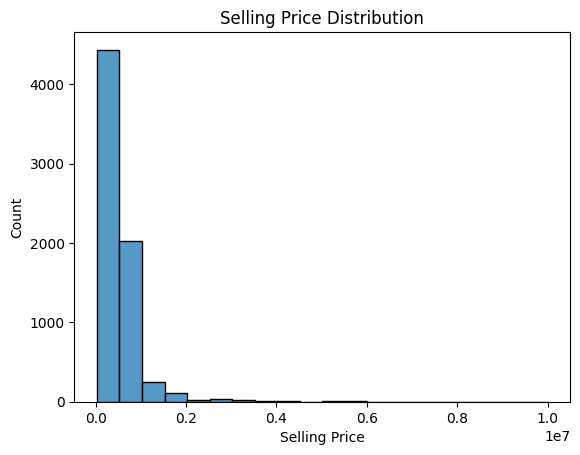

In [8]:
# Histogram using seaborn
sns.histplot(df['selling_price'], bins=20)

plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.ylabel("Count")

plt.show()

## 📊 Histogram (Seaborn)

This histogram shows the distribution of the selling price using Seaborn for better visualization.

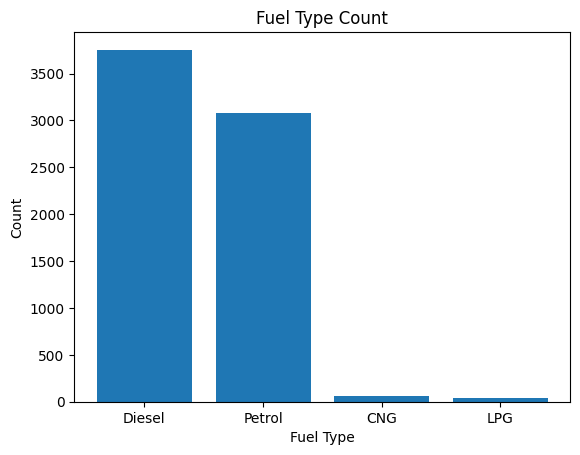

In [9]:
# Count values
counts = df['fuel'].value_counts()

# Bar chart
plt.bar(counts.index, counts.values)
plt.title("Fuel Type Count")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.show()

## 📊 Bar Chart

This bar chart shows the count of each category in the fuel column.  
It helps us understand which fuel type is most common in the dataset.

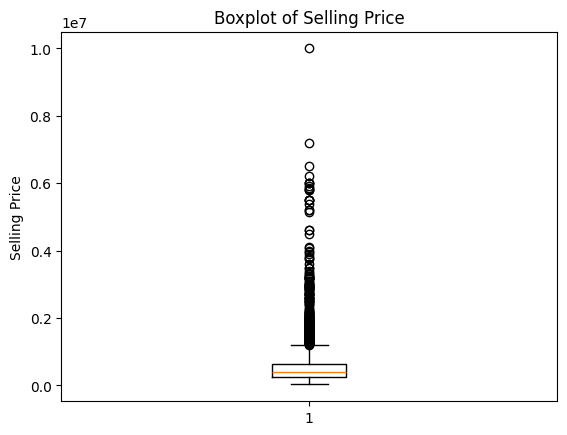

In [10]:
# Boxplot for selling_price
plt.boxplot(df['selling_price'])
plt.title("Boxplot of Selling Price")
plt.ylabel("Selling Price")
plt.show()

## 📊 Boxplot

A boxplot shows the spread of data and helps identify outliers.


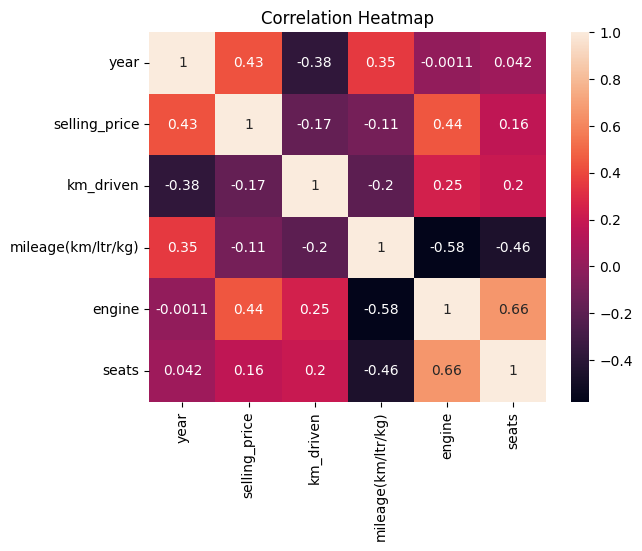

In [11]:
# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Heatmap
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

## 📊 Correlation Heatmap

This heatmap shows the relationship between numeric columns in the dataset.

##  Simple Prediction Model

In this step:
- Categorical columns are encoded into numeric form  
- Data is split into training (80%) and testing (20%) sets  
- A simple Linear Regression model is used to predict car prices  

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Convert categorical data
df = pd.get_dummies(df)

# Split data
X = df.drop('selling_price', axis=1)
y = df['selling_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Check accuracy
print(model.score(X_test, y_test))

0.8008901553598159


The model uses car features like year, fuel type, and kilometers driven to predict the selling price.  
After training, it compares predicted prices with actual prices to check accuracy.  
A higher score means the model is better at predicting car prices.

## 📊 Insights & Recommendations
### 🔍 Findings
**Finding 1:**  
The histogram of selling price shows that most cars are in the low to mid price range, indicating fewer expensive cars in the dataset.

**Finding 2:**  
The scatter plot (km driven vs selling price) shows that cars with higher kilometers driven generally have lower selling prices.

**Finding 3:**  
The boxplot of selling price shows some high-price outliers, meaning a few cars are priced much higher than the majority.

---
### 💡 Recommendations
**Recommendation 1:**  
Car sellers should keep the price competitive based on mileage, as buyers prefer cars with lower kilometers driven.
**Recommendation 2:**  
Buyers should compare prices with similar cars, especially for high-priced listings, to avoid overpaying for outlier-priced vehicles.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("cardekho.csv")

# Fill numerical columns with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Fill categorical columns with mode
df.fillna(df.mode().iloc[0], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Display first rows
print(df.head())

# Encoding categorical columns
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Define features and target
X = df.drop("selling_price", axis=1)

# target column
y = df["selling_price"]

# Split into train and test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
score = r2_score(y_test, y_pred)
print("R2 Score:", score)

                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner  mileage(km/ltr/kg)  engine  \
0  Individual       Manual   First Owner               23.40  1248.0   
1  Individual       Manual  Second Owner               21.14  1498.0   
2  Individual       Manual   Third Owner               17.70  1497.0   
3  Individual       Manual   First Owner               23.00  1396.0   
4  Individual       Manual   First Owner               16.10  1298.0   

  max_power  seats  
0        74    5.0  
1    103.52    5.0  
2        78    5.0  
3        90    5.0  
4      88.2